In [ ]:
%pip install pandas numpy fastplot tldextract

In [2]:
import json

import pandas as pd
from zipfile import ZipFile

import matplotlib.pyplot as plt
import fastplot as fpl
%matplotlib inline

from pathlib import Path

In [3]:
INPUT_DATA_DIR = Path("outputs-firefox-vs-chrome")
PLOTS_DIR = Path("plots-firefox-vs-chrome")
ADDITIONAL_DATA_DIR = Path(".")

VISITS = [ 'first', 'second' ]
VISITS_MAP = {
    ("first", "accept"): '\\textit{Before-Accept}',
    ("first", "deny"): '\\textit{Before-Deny}',
    ("first", "any"): '\\textit{Before-Click}',
    ("second", "accept"): '\\textit{After-Accept}',
    ("second", "deny"): '\\textit{After-Deny}'
}

FIELDS = [ 'contacted_domains', 'api_calls', 'cookies' ]
ACTIONS = [ 'accept', 'deny' ]

PRIVACY_SANDBOX_APIS_MAP = {
    'attribution_reporting': 'Attribution Reporting',
    'topics': 'Topics',
    'protected_audience': 'Protected Audience',
    'private_aggregation': 'Private Aggregation',
    'shared_storage': 'Shared Storage',
    'related_website_sets': 'Related Website Sets',
    "chips": 'CHIPS',
    'fenced_frames': 'Fenced Frames',
    'fedcm': 'FedCM',
    'private_state_tokens': 'Private State Tokens',
}
PRIVACY_SANDBOX_APIS = list(PRIVACY_SANDBOX_APIS_MAP.keys())

API_CALL_INTERCEPTION_TYPES = [ 'javascript_functions', 'cdp_events', "db_data" ]

TYPES_MAP = {
    "firefox": "Firefox",
    "chrome": "Chrome"
}

PLOT_ARGS = {"style":"latex", "grid":True, "figsize":(4.25,2.5), "rcParams":{'text.latex.preamble': '\\usepackage{libertine}\\usepackage{setspace}\n\\usepackage{courier}'}, "legend_args":{"columnspacing":1, "handlelength":1.5}}
PLOT_ARGS_LARGE = {"style":"latex", "grid":True, "figsize":(9,3.5), "rcParams":{'text.latex.preamble': '\\usepackage{libertine}\\usepackage{setspace}\n\\usepackage{courier}'}, "legend_args":{"columnspacing":1, "handlelength":1.5}}

In [4]:
import tldextract
extract = tldextract.TLDExtract(include_psl_private_domains=True)

def getGood2LD(url):
    if url == "UNKNOWN_SOURCE":
        return url
    return extract(url).top_domain_under_public_suffix

def getFullDomain(url):
    if url == "UNKNOWN_SOURCE":
        return url
    return extract(url).fqdn

with open(ADDITIONAL_DATA_DIR / "domain_map.json", "r") as file:
    de_map = json.load(file)

def is_third_party_domain(domain, other_domain):
    """A function defining whether a domains is third party with respect to another domain.
    Input
    -----
    domain (str): target domain
    other_domain (str): other domain
    Output
    ------
    bool: whether `other_domain` is third party with respect to `domain`
    """
    domain_etld1 = getGood2LD(domain)
    domain_en = de_map.get(domain_etld1, {'entityName': False})['entityName']
    other_domain_etld1 = getGood2LD(other_domain)
    other_domain_en = de_map.get(other_domain_etld1, {'entityName': False})['entityName']
    if "UNKNOWN_SOURCE" in (domain_etld1, other_domain_etld1):
        return False
    if domain_en==False or other_domain_en==False:
        if domain_etld1 != other_domain_etld1:
            return True
    elif domain_en != other_domain_en:
        return True
    return False

In [5]:
DEFAULT_HATCHES = [ "\\\\\\\\\\", "/////" ]
def set_bar_colors(plot, colors, legend=False, hatches=DEFAULT_HATCHES):
    if isinstance(colors, str):
        colors = [colors]
    x_len = len(plot.gca().get_xticklabels())
    for i,c in enumerate(colors):
        try:
            for p in plot.gca().patches[i*x_len:(i+1)*x_len] + ([plot.gca().get_legend().get_patches()[i]] if legend else []):
                p.set_hatch(hatches[i % len(hatches)])
                if isinstance(c, tuple):
                    p.set_edgecolor(c[0])
                    p.set_facecolor(c[1])
                elif isinstance(c, str):
                    p.set_edgecolor(c)
                    p.set_facecolor('white')
                else:
                    raise ValueError(f"Invalid color format: {c}. Expected tuple or string.")
        except IndexError:
            pass

def add_numbers_top(plot, numbers, title=None, y_level=None):
    if y_level is None:
        y_level = plot.gca().get_ylim()[1] * 1.05
    if title is not None:
        plot.gca().text(len(numbers)/2, y_level+(plot.gca().get_ylim()[1]*0.10), title, ha='center', fontsize=10)
    for i, v in enumerate(numbers):
        try:
            plot.gca().text(i, y_level, str(v), color='black', ha='center', fontsize=8)
        except IndexError:
            pass

def save_plot(plot, name, opts = { 'dpi':300 }):
    for ext in [ "pdf", "svg", "png" ]:
        plot.savefig(f"{PLOTS_DIR}/{ext}/{name}.{ext}", **opts)

def save_sankey(fig, name, opts = { }):
    for ext in [ "pdf", "svg", "png" ]:
        fig.write_image(f"{PLOTS_DIR}/{ext}/{name}.{ext}", **opts)

In [6]:
for subfolder in [ "pdf", "svg", "png" ]:
    (PLOTS_DIR / subfolder).mkdir(parents=True, exist_ok=True)

In [7]:
base_dir = Path(INPUT_DATA_DIR).expanduser()

crawling_frames = []

for zip_file in sorted(base_dir.iterdir()):
    if zip_file.suffix != ".zip":
        continue
    
    print(f'Reading {zip_file.name}')

    browser_type = zip_file.name.split("-")[-1][:-4]
    with ZipFile(zip_file, 'r') as archive:
        df_crawling = pd.read_csv(archive.open('crawler_outputs.csv')).assign(type=browser_type)

    crawling_frames.append(df_crawling)

df_crawling = pd.concat(crawling_frames)
df_crawling.head()

Reading outputs-20260105-chrome.zip
Reading outputs-20260105-firefox.zip


,position,website,first_contacted_domains_accept,first_api_calls_accept,first_cookies_accept,second_contacted_domains_accept,second_api_calls_accept,second_cookies_accept,first_contacted_domains_deny,first_api_calls_deny,first_cookies_deny,second_contacted_domains_deny,second_api_calls_deny,second_cookies_deny,type,button_content_accept,button_content_deny
0,1,https://www.google.com/,"[""fonts.gstatic.com"",""ogads-pa.clients6.google...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".google.com"",""expires"":1783119631....","[""fonts.gstatic.com"",""ogads-pa.clients6.google...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".google.com"",""expires"":1783378852....","[""fonts.gstatic.com"",""ogads-pa.clients6.google...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".google.com"",""expires"":1783119632....","[""fonts.gstatic.com"",""ogads-pa.clients6.google...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".google.com"",""expires"":1783119632....",chrome,NaN,NaN
1,3,https://www.microsoft.com/it-it/,"[""assets.adobedtm.com"",""b.clarity.ms"",""browser...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":""www.microsoft.com"",""expires"":17675...","[""adservice.google.com"",""api.company-target.co...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":""www.microsoft.com"",""expires"":17675...","[""assets.adobedtm.com"",""b.clarity.ms"",""browser...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":""www.microsoft.com"",""expires"":17675...","[""assets.adobedtm.com"",""b.clarity.ms"",""browser...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":""www.microsoft.com"",""expires"":17675...",chrome,NaN,NaN
2,4,https://www.facebook.com/,"[""facebook.com"",""static.xx.fbcdn.net"",""www.fac...","{""topics"":{""javascript_functions"":[],""cdp_even...",[],"[""facebook.com"",""static.xx.fbcdn.net"",""www.fac...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".facebook.com"",""expires"":180212766...","[""facebook.com"",""static.xx.fbcdn.net"",""www.fac...","{""topics"":{""javascript_functions"":[],""cdp_even...",[],"[""facebook.com"",""static.xx.fbcdn.net"",""www.fac...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".facebook.com"",""expires"":180212766...",chrome,NaN,NaN
3,5,https://www.cloudflare.com/,"[""cf-assets.www.cloudflare.com"",""challenges.cl...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".cloudflare.com"",""expires"":1767569...","[""713-xsc-918.mktoresp.com"",""adservice.google....","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".cloudflare.com"",""expires"":1767569...","[""cf-assets.www.cloudflare.com"",""challenges.cl...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".cloudflare.com"",""expires"":1767569...","[""cf-assets.www.cloudflare.com"",""challenges.cl...","{""topics"":{""javascript_functions"":[],""cdp_even...","[{""domain"":"".cloudflare.com"",""expires"":1767569...",chrome,NaN,NaN
4,6,https://googleapis.com/,"[""googleapis.com"",""www.google.com""]","{""topics"":{""javascript_functions"":[],""cdp_even...",[],NaN,NaN,NaN,"[""googleapis.com"",""www.google.com""]","{""topics"":{""javascript_functions"":[],""cdp_even...",[],NaN,NaN,NaN,chrome,NaN,NaN


In [8]:
types = df_crawling["type"].unique().tolist()

In [9]:
# df_crawling["website_2ld"] = df_crawling["website"].apply(getGood2LD)

# # Get set of websites per type
# df_websites_per_type = (
#     df_crawling[["type", "website_2ld"]]
#         .drop_duplicates()
#         .groupby("type")
#         .agg(set)
#         .reset_index()
# )

# # Get common websites across all types
# common_websites = set.intersection(*df_websites_per_type["website_2ld"])
# print(f"Found {len(common_websites)} common websites across all types.")

# # Filter only common websites
# df_crawling = df_crawling[df_crawling["website_2ld"].isin(common_websites)]

In [10]:
for visit in VISITS:
    for field in FIELDS:
        for action in ACTIONS:
            mk_not_null = ~df_crawling[f"{visit}_{field}_{action}"].isna()
            df_crawling.loc[mk_not_null, f"{visit}_{field}_{action}"] = df_crawling.loc[mk_not_null, f"{visit}_{field}_{action}"].apply(json.loads)

In [11]:
for visit in VISITS:
    for action in ACTIONS:
        mk_cookies_object = df_crawling[f"{visit}_cookies_{action}"].apply(lambda x: isinstance(x, dict))
        df_crawling.loc[mk_cookies_object, f"{visit}_cookies_{action}"] = df_crawling.loc[mk_cookies_object, f"{visit}_cookies_{action}"].apply(lambda x: x["cookies"])

In [12]:
mk_no_visits = df_crawling[[f"{visit}_cookies_{action}" for visit in VISITS for action in ACTIONS]].isna().all(axis=1)
rows_no_visits = mk_no_visits.sum()
df_crawling = df_crawling[~mk_no_visits]
print(f"Removed {rows_no_visits} row(s) without any visits.")

Removed 0 row(s) without any visits.


In [13]:
# Define partitioned cookies, i.e., cookies with a set partition key
for visit in VISITS:
    for action in ACTIONS:
        df_crawling[f"{visit}_partitioned_cookies_{action}"] = df_crawling[f"{visit}_cookies_{action}"].apply(lambda cookies: [c for c in cookies if 'partitionKey' in c and c['partitionKey'] is not None] if isinstance(cookies, list) else None)

In [14]:
COLS = [ "type", "cookie_domain", "visit", "action", "is_partitioned" ]

cookies_visit_frames = []

def get_cookie_info(row):
    common_info = {
        "type": row["type"],
        "website": row["website"],
        "visit": visit,
        "action": action,
        "button_content_accept": row.get("button_content_accept", None),
        "button_content_deny": row.get("button_content_deny", None)
    }

    cookie = row[f"{visit}_cookies_{action}"]
    if row["type"] == "firefox":
        cookie_info = {
            "name": cookie["name"],
            "cookie_domain": getGood2LD(cookie["host"]),
            "cookie_domain_full": getFullDomain(cookie["host"]),
            "is_partitioned": 'partitionKey' in cookie["originAttributes"],
            "is_session": cookie.get("expiry", None) is None
        }
    else:
        cookie_info = {
            "name": cookie["name"],
            "cookie_domain": getGood2LD(cookie["domain"]),
            "cookie_domain_full": getFullDomain(cookie["domain"]),
            "is_partitioned": 'partitionKey' in cookie and cookie['partitionKey'] is not None,
            "is_session": cookie.get("session", False)
        }

    return { **common_info, **cookie_info }

for action in ACTIONS:
    for visit in VISITS:
        print("Processing", visit, action)
        df_cookies_visit = (
            df_crawling[["type", "website", f"{visit}_cookies_{action}", "button_content_accept", "button_content_deny"]]
                .explode(f"{visit}_cookies_{action}")
                .dropna(subset=[f"{visit}_cookies_{action}"])
                .apply(lambda row: pd.Series(get_cookie_info(row)), axis="columns")
        )
        cookies_visit_frames.append(df_cookies_visit)

df_cookies = pd.concat(cookies_visit_frames)

df_cookies.head()

Processing first accept
Processing second accept
Processing first deny
Processing second deny


,type,website,visit,action,button_content_accept,button_content_deny,name,cookie_domain,cookie_domain_full,is_partitioned,is_session
0,chrome,https://www.google.com/,first,accept,NaN,NaN,AEC,google.com,google.com,False,False
0,chrome,https://www.google.com/,first,accept,NaN,NaN,__Secure-BUCKET,google.com,google.com,False,False
0,chrome,https://www.google.com/,first,accept,NaN,NaN,__Secure-ENID,google.com,google.com,False,False
0,chrome,https://www.google.com/,first,accept,NaN,NaN,EUULE,google.com,www.google.com,False,False
1,chrome,https://www.microsoft.com/it-it/,first,accept,NaN,NaN,.AspNetCore.OpenIdConnect.Nonce.CfDJ8NW1sga3Nm...,microsoft.com,www.microsoft.com,False,False


In [15]:
# Filter out session cookies
mk_session = df_cookies["is_session"]
df_cookies = df_cookies[~mk_session]
print(f"Filtered out {mk_session.sum()} session cookies.")

Filtered out 44703 session cookies.


In [16]:
mk_firefox_filter = (
    df_cookies["type"].eq("firefox")
    & df_cookies["action"].eq("accept")
    & df_cookies["name"].isin([ '__Host-GAPS', '__Secure-ENID', 'OTZ' ])
    & df_cookies["button_content_accept"].eq("continue")
)
df_cookies = df_cookies[~mk_firefox_filter]
print(f"Filtered out {mk_firefox_filter.sum()} cookies from Firefox 'Continue' button on google.com.")

Filtered out 295 cookies from Firefox 'Continue' button on google.com.


In [17]:
mk_tp_cookies = ~df_cookies["website"].str.startswith("data-placeholder") & df_cookies[["website", "cookie_domain"]].apply(lambda row: is_third_party_domain(row["website"], row["cookie_domain"]), axis=1)
df_tp_cookies = df_cookies[mk_tp_cookies]
df_fp_cookies = df_cookies[~mk_tp_cookies]

In [18]:
df_total_websites = df_crawling[[ "first_cookies_accept", "first_cookies_deny", "second_cookies_accept" ]].copy()
df_total_websites["first_cookies_accept"] = df_total_websites["first_cookies_accept"].combine_first(df_total_websites["first_cookies_deny"])
df_total_websites = (
    df_crawling
        .pivot_table(columns="type", values=[ "first_cookies_accept", "second_cookies_accept", "second_cookies_deny" ], aggfunc="count")
        .rename(index={ **{ f"second_cookies_{action}": f"second_{action}" for action in ACTIONS }, **{ f"first_cookies_accept": "first" } })
        .transpose()
)

df_total_websites

,first,second_accept,second_deny
type,,,
chrome,8152,3247,2202
firefox,7849,3409,2239


Plotting TP cookies for first accept...


<Figure size 640x480 with 0 Axes>

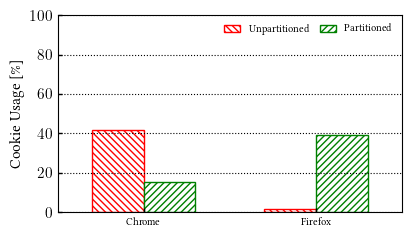

Plotting TP cookies for second accept...


<Figure size 640x480 with 0 Axes>

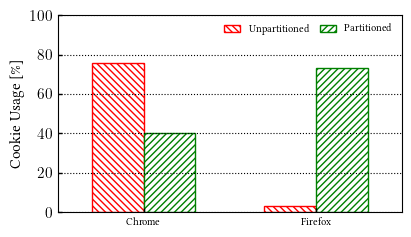

Plotting TP cookies for second deny...


<Figure size 640x480 with 0 Axes>

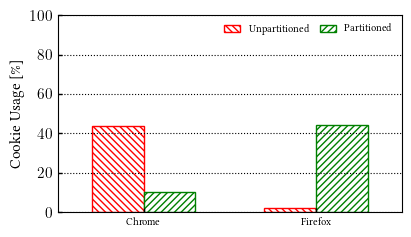

In [19]:
for visit in VISITS:
    for action in ACTIONS:
        
        # For accept: consider only second-accept visit, or any of the first visits
        if visit == "first":
            visit_name = "first"
            if action == "deny":
                continue
            mk_cookies_visit_action = df_tp_cookies["visit"].eq("first")
        else:
            visit_name = f"second_{action}"
            mk_cookies_visit_action = df_tp_cookies["visit"].eq("second") & df_tp_cookies["action"].eq(action)

        print(f"Plotting TP cookies for {visit} {action}...")
        df_tp_cookies_visit = df_tp_cookies[mk_cookies_visit_action]

        df_cookie_websites_by_visit_partition_type = df_tp_cookies_visit.pivot_table(index="type", columns="is_partitioned", values="website", aggfunc="nunique")

        df_cookie_percentage_by_visit_partition_type = 100 * df_cookie_websites_by_visit_partition_type.div(df_total_websites[visit_name], axis="rows")

        df_plot = df_cookie_percentage_by_visit_partition_type.rename(
            index=TYPES_MAP,
            columns={
                True: "Partitioned",
                False: "Unpartitioned"
            }
        )
        plot = fpl.plot(
            df_plot,
            path=None,
            mode='bars_multi',
            xticks_fontsize="x-small",#  xticks_rotate = 30,
            ylabel='Cookie Usage [\\%]', ylim=(0,100),
            grid_axis="y",
            legend = True, legend_loc='upper right', legend_ncol=3, legend_fontsize="x-small",
            **PLOT_ARGS
        )
        set_bar_colors(plot, colors=["red", "green"], legend=True)
        save_plot(plot, f"tp-cookies-partitioned-percentage-by-date-{visit}-{action}")
        plot.show()

Top 15 cookie domains for chrome - First-Accept visit, Partitioned cookies


<Figure size 640x480 with 0 Axes>

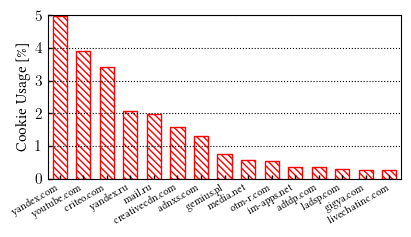

Top 15 cookie domains for chrome - First-Accept visit, Unpartitioned cookies


<Figure size 640x480 with 0 Axes>

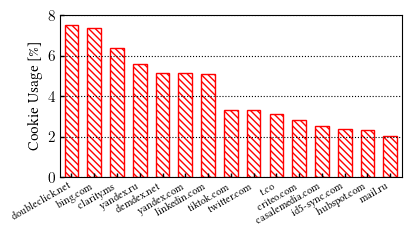

Top 15 cookie domains for chrome - Second-Accept visit, Partitioned cookies


<Figure size 640x480 with 0 Axes>

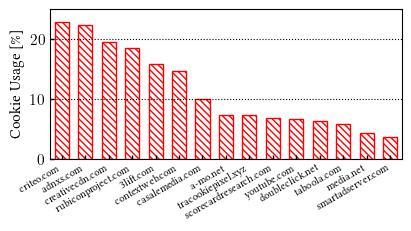

Top 15 cookie domains for chrome - Second-Accept visit, Unpartitioned cookies


<Figure size 640x480 with 0 Axes>

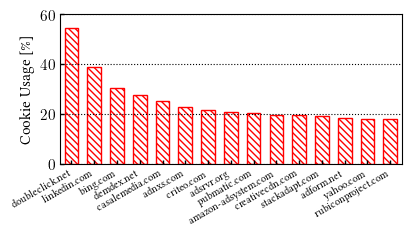

Top 15 cookie domains for chrome - Second-Deny visit, Partitioned cookies


<Figure size 640x480 with 0 Axes>

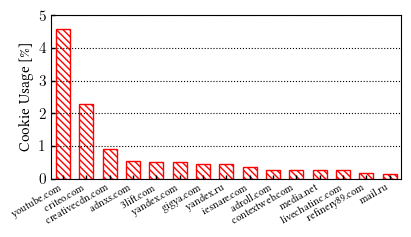

Top 15 cookie domains for chrome - Second-Deny visit, Unpartitioned cookies


<Figure size 640x480 with 0 Axes>

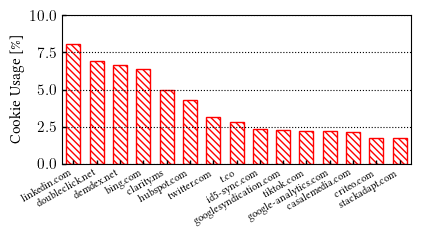

Top 15 cookie domains for firefox - First-Accept visit, Partitioned cookies


<Figure size 640x480 with 0 Axes>

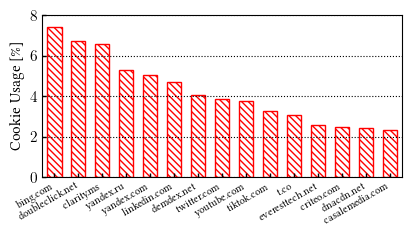

Top 15 cookie domains for firefox - First-Accept visit, Unpartitioned cookies


<Figure size 640x480 with 0 Axes>

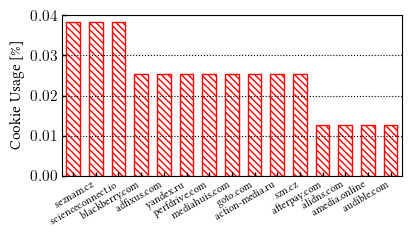

Top 15 cookie domains for firefox - Second-Accept visit, Partitioned cookies


<Figure size 640x480 with 0 Axes>

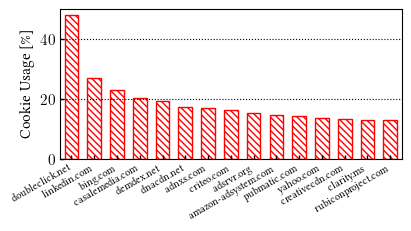

Top 15 cookie domains for firefox - Second-Accept visit, Unpartitioned cookies


<Figure size 640x480 with 0 Axes>

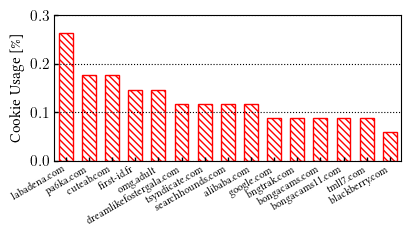

Top 15 cookie domains for firefox - Second-Deny visit, Partitioned cookies


<Figure size 640x480 with 0 Axes>

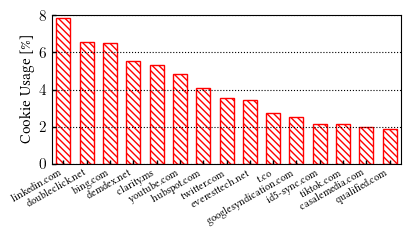

Top 15 cookie domains for firefox - Second-Deny visit, Unpartitioned cookies


<Figure size 640x480 with 0 Axes>

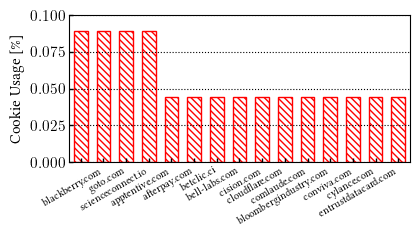

In [20]:
df_tp_cookies_2ld = df_tp_cookies.copy()
df_tp_cookies_2ld["cookie_domain"] = df_tp_cookies_2ld["cookie_domain"].apply(getGood2LD)
df_tp_cookies_2ld = df_tp_cookies_2ld[["type", "visit", "action", "website", "cookie_domain", "is_partitioned"]].drop_duplicates()

for browser_type in types:
    for visit in VISITS:
        for action in ACTIONS:
            if visit == "first" and action != "accept":
                continue
            for is_partitioned in [ True, False ]:
                print(f"Top 15 cookie domains for {browser_type} - {visit.capitalize()}-{action.capitalize()} visit, {'Partitioned' if is_partitioned else 'Unpartitioned'} cookies")
                df_type_visit_action = df_tp_cookies_2ld[df_tp_cookies_2ld["type"].eq(browser_type) & df_tp_cookies_2ld["is_partitioned"].eq(is_partitioned)]
                if visit == "first":
                    df_type_visit_action = df_type_visit_action[df_type_visit_action["visit"] == visit]
                else:
                    df_type_visit_action = df_type_visit_action[df_type_visit_action["visit"].eq(visit) & df_type_visit_action["action"].eq(action)]

                df_count_websites_by_cookie_domain = df_type_visit_action.pivot_table(index="cookie_domain", values="website", aggfunc="nunique")
                df_count_websites_by_cookie_domain_top = df_count_websites_by_cookie_domain.sort_values(by="website", ascending=False).head(15)

                visit_name = visit if visit == "first" else f"{visit}_{action}"
                total_websites = df_total_websites.loc[browser_type, visit_name]
                df_count_websites_by_cookie_domain_top["percentage"] = 100 * df_count_websites_by_cookie_domain_top["website"] / total_websites

                plot_data = [
                    (cookie_domain, count) for cookie_domain, count in zip(
                        df_count_websites_by_cookie_domain_top.index,
                        df_count_websites_by_cookie_domain_top["percentage"].values
                    )
                ]
                plot = fpl.plot(
                    plot_data,
                    path=None,
                    mode='bars',
                    xticks_fontsize="x-small", xticks_rotate = 30,
                    ylabel='Cookie Usage [\\%]',
                    grid_axis="y",
                    **PLOT_ARGS
                )
                set_bar_colors(plot, colors="red")
                save_plot(plot, f"tp-cookies-top15-cookie-domains-percentage-{browser_type}-{visit}-{action}-{'partitioned' if is_partitioned else 'unpartitioned'}")
                plot.show()